In [2]:
import os
import xarray as xr
import numpy as np
from cdo import Cdo
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tempfile

from eoceneNEMO import EoceneNEMO

cdo = Cdo()

In [3]:
eocene = EoceneNEMO(
    herold_folder="/lus/h2resw01/hpcperm/ecme3497/herold-et-al-2014/Supp",
    input_folder="/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2",
    output_folder="/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC"
)

# Tidal Mixing

In [4]:
eocene.create_tidal_mixing()

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/lus/h2resw01/hpcpe

## Sanity Check

In [4]:
tidal_mixing = "/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/nemo/initial/zdfiwm_forcing_r720x360.nc"

tm = xr.open_dataset(tidal_mixing)

print(tm)

<xarray.Dataset> Size: 15MB
Dimensions:     (latitude: 360, longitude: 720)
Coordinates:
  * latitude    (latitude) float64 3kB -90.0 -89.5 -89.0 ... 88.5 89.0 89.5
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables:
    power_bot   (latitude, longitude) float64 2MB ...
    power_cri   (latitude, longitude) float64 2MB ...
    power_nsq   (latitude, longitude) float64 2MB ...
    power_sho   (latitude, longitude) float64 2MB ...
    scale_cri   (latitude, longitude) float64 2MB ...
    scale_bot   (latitude, longitude) float64 2MB ...
    bathymetry  (latitude, longitude) float64 2MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    Conventions:               CF-1.6
    history:                   Sun Aug 04 00:59:55 2024: cdo -L -P 16 -remapn...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  16


In [5]:
herold = xr.open_dataset(
    "/lus/h2resw01/hpcperm/ecme3497/herold-et-al-2014/Supp/Green_Huber_eocene_tidal_dissipation_r720x360.nc"
)

m2 = herold["eo_tidal_dissipation"]

print (m2)

<xarray.DataArray 'eo_tidal_dissipation' (lat: 360, lon: 720)> Size: 2MB
[259200 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
Attributes:
    long_name:  Eocene tidal dissipation
    units:      W/m^2


In [6]:
pd_file = "/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/nemo/initial/zdfiwm_forcing_r720x360.nc"

ds_pd = xr.open_dataset(pd_file)
present_day = ds_pd["power_cri"]
present_day = present_day.rename({
    "latitude": "lat",
    "longitude": "lon"
})

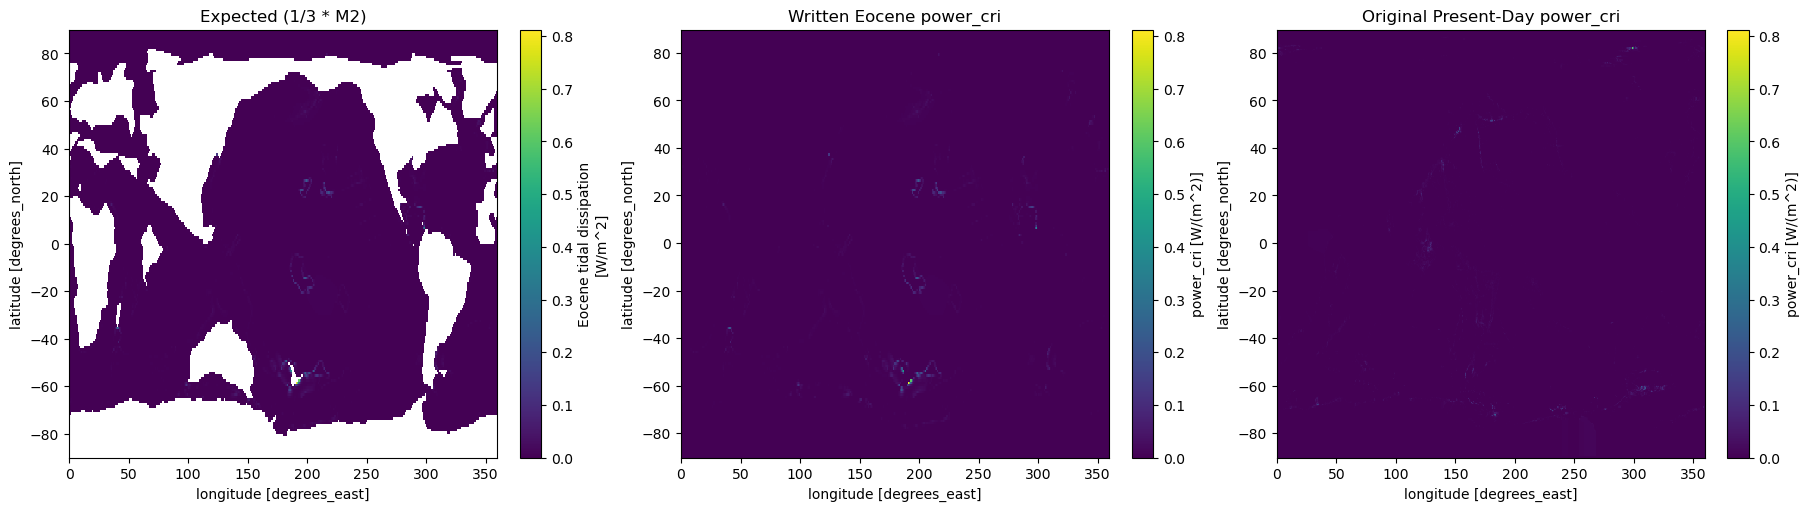

In [7]:
expected = (1/3) * m2
actual = tm["power_cri"]

# Make sure dims match
actual = actual.rename({"latitude": "lat", "longitude": "lon"})

vmin = float(expected.min())
vmax = float(expected.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Panel 1 — Expected
expected.plot(
    ax=axes[0],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("Expected (1/3 * M2)")

# Panel 2 — Written Eocene
actual.plot(
    ax=axes[1],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Written Eocene power_cri")

# Panel 3 — Present Day
present_day.plot(
    ax=axes[2],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
axes[2].set_title("Original Present-Day power_cri")

plt.show()


# Geothermal Bottom Flux

In [5]:
eocene.create_geothermal_flux()

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/lus/h2resw01/hpcpe

## Sanity check

In [9]:
geothermal_flux = "/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/nemo/initial/Goutorbe_ghflux.nc" 
gf = xr.open_dataset(geothermal_flux)
gf_eoc =gf["gh_flux"].isel(time=0)
print(gf_eoc)

<xarray.DataArray 'gh_flux' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    time     float64 8B 1.0
Attributes:
    long_name:    Geothermal heat flux from Goutorbe et al. (2011)
    units:        mW m^{-2}
    valid_range:  [   0. 1000.]


In [10]:
gf_pd = "/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/nemo/initial/Goutorbe_ghflux.nc" 
gf_pd = xr.open_dataset(gf_pd) 
gf_pd =gf_pd["gh_flux"].isel(time=0)
print(gf_pd)

<xarray.DataArray 'gh_flux' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
    time     float64 8B 1.0
Attributes:
    long_name:    Geothermal heat flux from Goutorbe et al. (2011)
    units:        mW m^{-2}
    valid_range:  [   0. 1000.]


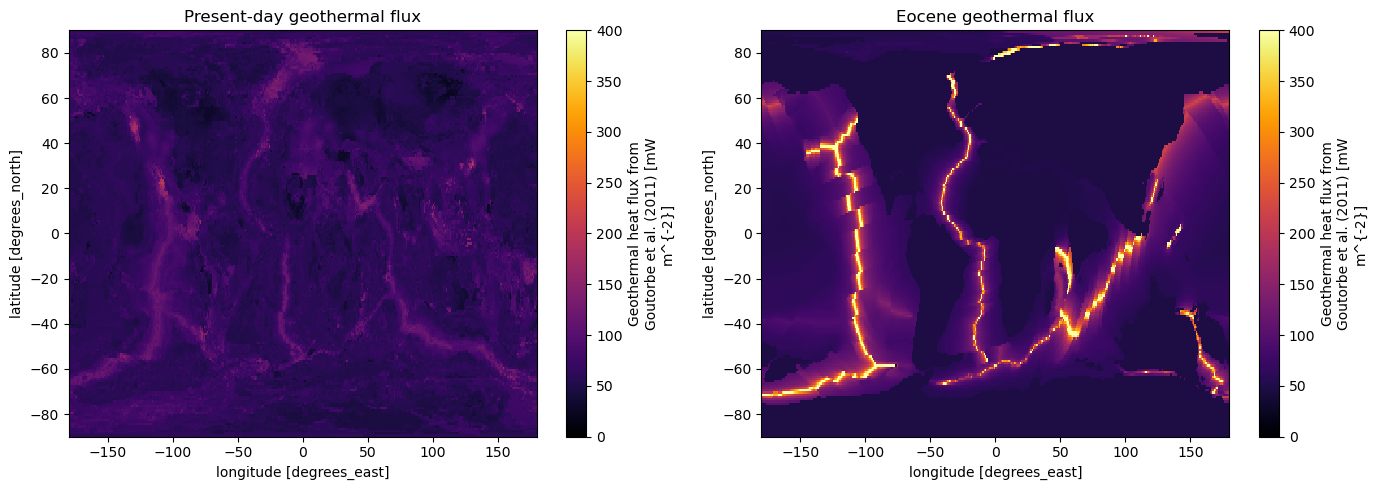

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 — Present day
gf_pd.plot(
    ax=axes[0],
    cmap="inferno",
    vmin=0,
    vmax=400
)
axes[0].set_title("Present-day geothermal flux")

# Panel 2 — Eocene
gf_eoc.plot(
    ax=axes[1],
    cmap="inferno",
    vmin=0,
    vmax=400
)
axes[1].set_title("Eocene geothermal flux")

plt.tight_layout()
plt.show()

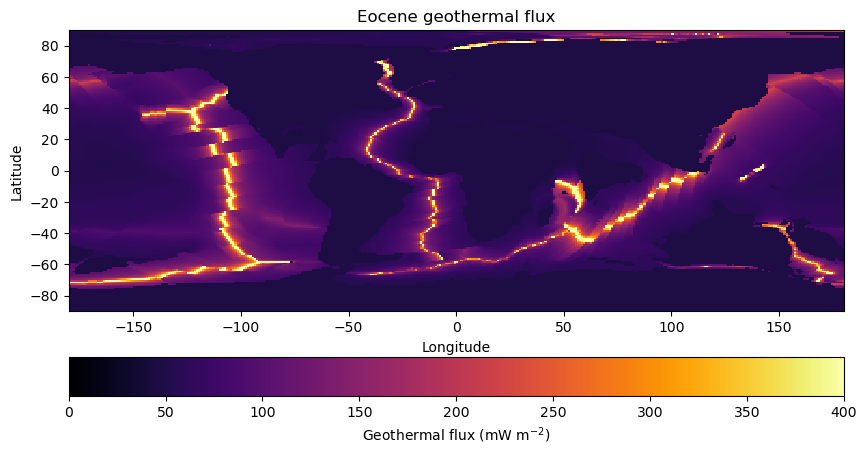

In [12]:
# convert longitude from 0–360 → -180–180
gf_eoc = gf_eoc.assign_coords(lon=((gf_eoc.lon + 180) % 360) - 180)
gf_eoc = gf_eoc.sortby("lon")

fig, ax = plt.subplots(figsize=(10,5))

gf_eoc.plot(
    ax=ax,
    cmap="inferno",
    vmin=0,
    vmax=400,
    cbar_kwargs={
        "orientation": "horizontal",
        "pad": 0.12,
        "label": "Geothermal flux (mW m$^{-2}$)"
    }
)

ax.set_title("Eocene geothermal flux")

# enforce axis limits
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()



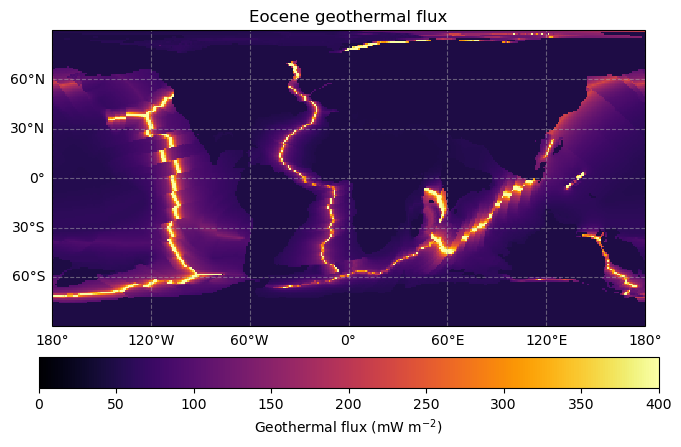

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# convert longitude 0–360 → -180–180 if needed
gf_eoc = gf_eoc.assign_coords(lon=((gf_eoc.lon + 180) % 360) - 180)
gf_eoc = gf_eoc.sortby("lon")

proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(10,5),
    subplot_kw={"projection": proj}
)

im = gf_eoc.plot(
    ax=ax,
    transform=proj,
    cmap="inferno",
    vmin=0,
    vmax=400,
    add_colorbar=False
)

ax.set_global()
#ax.coastlines()

# gridlines with lat/lon labels
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# horizontal colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.08,
    shrink=0.8,
    label="Geothermal flux (mW m$^{-2}$)"
)

ax.set_title("Eocene geothermal flux")

plt.show()



# Initial Conditions: t-so

In [6]:
eocene.create_ocean_init()


/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/nemo/eoceneNEMO.py:156: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  woa = xr.open_dataset(woa_file, chunks={"z": 1})
HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is

<xarray.Dataset> Size: 33MB
Dimensions:       (z: 31, y: 180, x: 360, time_counter: 12)
Coordinates:
  * z             (z) float32 124B 5.0 15.0 25.0 ... 4.25e+03 4.75e+03 5.25e+03
  * time_counter  (time_counter) float32 48B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Dimensions without coordinates: y, x
Data variables:
    thetao        (z, y, x) float64 16MB 10.21 10.21 10.21 ... 10.0 10.0 10.0
    so            (z, y, x) float64 16MB 34.7 34.7 34.7 34.7 ... 34.7 34.7 34.7
    lon           (y, x) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
    lat           (y, x) float64 518kB dask.array<chunksize=(180, 360), meta=np.ndarray>
Attributes:
    CDI:            Climate Data Interface version 1.9.10 (https://mpimet.mpg...
    Conventions:    CF-1.6
    creation_date:  Wed Jun 10 10:34:40 CEST 2015
    script_name:    /home/globc/sanchez/WORK/TEOS10/5_compute_teos10.ncl
    ece-comment:    From SHACONEMO INPUTS_ORCA1_LIM3_PISCES_V9/INPUTS_ORCA025...
    ece-origin:     UFla (SMHI) for EC-Earth
    CDO:            Climate Data Operators version 1.9.10 (https://mpimet.mpg...

## Sanity check

In [4]:
initial_conditions_eoc = "/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/nemo/initial/woa13-levitus-L31_deepmip-34.nc"

ic_eo = xr.open_dataset(initial_conditions_eoc)

print(ic_eo)

<xarray.Dataset> Size: 33MB
Dimensions:       (z: 31, y: 180, x: 360, time_counter: 12)
Coordinates:
  * z             (z) float32 124B 5.0 15.0 25.0 ... 4.25e+03 4.75e+03 5.25e+03
  * time_counter  (time_counter) float32 48B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Dimensions without coordinates: y, x
Data variables:
    thetao        (z, y, x) float64 16MB ...
    so            (z, y, x) float64 16MB ...
    lon           (y, x) float64 518kB ...
    lat           (y, x) float64 518kB ...
Attributes:
    CDI:            Climate Data Interface version 1.9.10 (https://mpimet.mpg...
    Conventions:    CF-1.6
    creation_date:  Wed Jun 10 10:34:40 CEST 2015
    script_name:    /home/globc/sanchez/WORK/TEOS10/5_compute_teos10.ncl
    ece-comment:    From SHACONEMO INPUTS_ORCA1_LIM3_PISCES_V9/INPUTS_ORCA025...
    ece-origin:     UFla (SMHI) for EC-Earth
    CDO:            Climate Data Operators version 1.9.10 (https://mpimet.mpg...


In [5]:
initial_conditions_pd = f"{eocene.input_folder}/nemo/initial/woa13-levitus-L31.nc"

ic_pd = xr.open_dataset(initial_conditions_pd)

print(ic_pd)

<xarray.Dataset> Size: 194MB
Dimensions:       (time_counter: 12, z: 31, y: 180, x: 360)
Coordinates:
  * time_counter  (time_counter) float32 48B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Dimensions without coordinates: z, y, x
Data variables:
    thetao        (time_counter, z, y, x) float32 96MB ...
    so            (time_counter, z, y, x) float32 96MB ...
    lon           (y, x) float64 518kB ...
    lat           (y, x) float64 518kB ...
Attributes:
    CDI:            Climate Data Interface version 1.9.10 (https://mpimet.mpg...
    Conventions:    CF-1.6
    creation_date:  Wed Jun 10 10:34:40 CEST 2015
    script_name:    /home/globc/sanchez/WORK/TEOS10/5_compute_teos10.ncl
    ece-comment:    From SHACONEMO INPUTS_ORCA1_LIM3_PISCES_V9/INPUTS_ORCA025...
    ece-origin:     UFla (SMHI) for EC-Earth
    CDO:            Climate Data Operators version 1.9.10 (https://mpimet.mpg...


In [7]:
old_temp = ic_pd["thetao"].isel(z=0)
new_temp = ic_eo["thetao"].isel(z=0)

# Use lat/lon grid from the datasets
old_lat, old_lon = ic_pd["lat"], ic_pd["lon"]
new_lat, new_lon = ic_eo["lat"], ic_eo["lon"]

In [8]:
vmin = min(old_temp.min().item(), new_temp.min().item())
vmax = max(old_temp.max().item(), new_temp.max().item())

TypeError: Dimensions of C (12, 180, 360) should be one smaller than X(360) and Y(180) while using shading='flat' see help(pcolormesh)

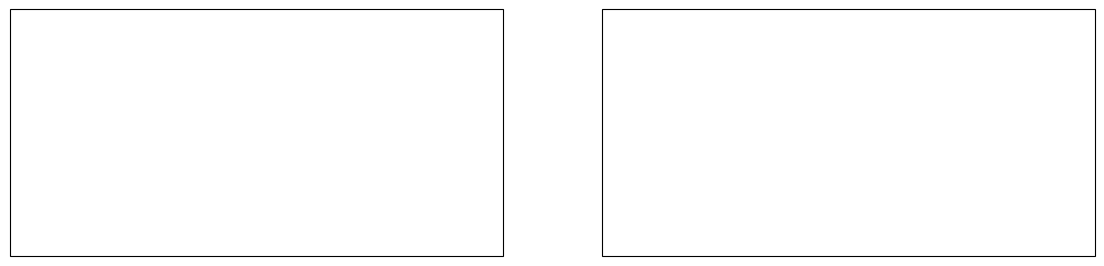

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Present-day
pcm = axes[0].pcolormesh(old_lon, old_lat, old_temp, cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0].coastlines()
axes[0].set_title("Present-day SST")

# Eocene
pcm = axes[1].pcolormesh(new_lon, new_lat, new_temp, cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1].coastlines()
axes[1].set_title("Eocene SST")

fig.colorbar(pcm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
plt.show()
